<a href="https://colab.research.google.com/github/RahulSwami151/Celebal_2027/blob/main/Week_5%3CRahul_Swami%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense,Dropout
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [13]:
corpus = '''
One more wedding. That’s what she’d told herself. Her portrait studio was already up and running, and she was done with the traveling and the fourteen-hour days and the family drama. Just one last wedding.

	Jacqui checked the time on her phone for the umpteenth time and inhaled deeply. Screw it, the mindful breathing wasn’t cutting it. She caught the bartender’s eye. “Whiskey, please. Neat.”

	She normally never drank at weddings–at least not until she clocked off. But this uncertainty was doing her head in.

	She shouldn’t have agreed to the job, but it was Celia. Plus the new studio lights were expensive, and the groom was minted. Like, banking-money minted. This wedding was leaking money, from the exclusive manor-hotel venue with its manicured lawns, uniformed staff, open bar, to Celia’s dress, which Jacqui knew had been a gift from the groom’s corporate lawyer father. Celia had whispered that it cost “two months’s rent.” Who knew how much that might mean.

	Plus, she’d known Celia since grammar school in Cork. It would be like turning down family; she’d never have heard the end of it.

	But then Celia had moved the wedding back two hours, and now Jacqui was screwed. She let the whiskey slide down her throat and its warmth seep up her spine.

	How the hell to explain to a bride that you couldn’t take pictures during golden hour because of magic.

	She should have cancelled.

	The last time Jacqui had shot a wedding at golden hour, the bride’s politician brother had appeared in every picture with a blurred mouth. He was arrested a week later on corruption charges, and every paper in the country had run headlines using the word ‘liar.’ Before that, it had been her own cousin’s university graduation, where he’d appeared transparent around the edges in every photo. A year later he’d abandoned medical school and cut ties with the family. Was now living in New Zealand, a diving instructor.

	Jacqui never knew what truth might be revealed, or how cryptic or obvious it would be. She only knew she didn’t want the knowledge.

	Curse the golden hour. And curse whichever social media wedding influencer Celia was following who had no doubt insisted the perfect wedding had to have flawless photos taken in the purest light, so her skin would look magazine-cover exquisite.

	Oh, this was nuts. Why wasn’t she at home on her couch with Andy and Luna, drinking pinot and watching something benign on telly? Maybe Ted Lasso or even Breaking Bad. Something old. Something with an ending she already knew.

	The wedding planner was even now corralling the families towards the manor’s water feature. It would be fine if there was a chance in hell it would take less than twenty minutes to herd them all to one place, but wedding party guests were basically cats when it came to organization. Even now they were milling around, new ones wandering off as lost ones returned.

	Celia appeared on the grass, framed by the pristine white french doors of the bar area, which led onto the lawn. Gorgeous. And sweet. Did not deserve what was coming.

	What might be coming? Jacqui liked the revised verb. Surely there had to be a chance that it wouldn’t happen again. Surely. Oh, quit kidding yourself. This had happened too many times to pretend and in too many different contexts. The magic worked on any camera, fancy or plain, expensive or crap.

	Out there on the green, Celia was clearly at her wits’ end, searching for wayward relatives. It would be the twenty-somethings. Since they weren’t here at the bar, they were either at the hotel lounge, or in some corner having a sneaky spliff.

	The bride looked to her right, just at that moment, still framed beautifully, the golden hour just about to make its glorious appearance and transform the light into magic, figuratively. And literally.

	Jacqui raised her water glass and Celia returned an exasperated smile just as Gavin joined her. As the couple spoke, heads bent towards each other, love clear on both faces, Jacqui raised her phone and snapped a shot. Heart pounding, she checked the image.

	On the screen, Celia was kissing air. The groom had vanished.

	There on the grass, solid and substantial; in the photo, absent.

	In the years since this golden hour trouble had started, she'd seen lies, grief, ghosts and once a man whose shadow walked three feet ahead of him. She'd never seen a bride or groom simply disappear.

	“Bollocks.”

	The bartender raised her eyebrows and tilted her head towards the whiskey, suggesting another drink.

	“I wish. But no, thanks.”

	 Maybe she could fake a robbery of all her cameras. At least for an hour. She played the scenario out in her head: she’d exit the main bar carrying all her gear, and then come back moments later claiming a theft? Right.

	She could feign illness. Some kind of sickness so debilitating that she couldn’t hold out for one hour…like a heart attack? Cue: a lifetime of guilt. Celia’s father had died of a heart attack. No, Jacqui couldn’t take the entire wedding down like that.

	There was always the truth. After all, Celia’d grown up in Cork, where every family possessed at least one story nobody could quite explain. But no. This was her husband, and her wedding day.

	Perhaps she should check again. Jacqui slid off her barstool and approached the french doors. From the threshold, she snapped a few more of the crowd. Several of Gavin, specifically, who looked perfect in this flood of golden light.

	She swiped through. There he was in the ceremony, saying his vows, holding the ring, kissing the bride, and walking up the aisle afterwards. All present and correct. But another swipe and there they all were, the whole wedding party, outside–all but Gavin. The groom was missing. Double bollocks.

	Scanning the shots, in case some additional disaster had yet to reveal itself to her, it didn’t appear that any other guests were affected. Thank Hecate for that.

	“I know it’s getting late. We’re almost ready, I swear.”

	Jacqui jolted. It was Celia, who’d approached on stealthy-bride Manolos.

	“Oh–Hey. It’s fine. It’s nothing. Take your time.”

	“Is everything alright? Your expression…are the photos okay?”

	The eagerness in her bright blue eyes belied the question. Celia didn’t actually believe anything would be wrong with the pictures. This wasn’t even the right camera, just a phone. All the good, important shots would be on the expensive gear.

	“Totally fine! I was just checking–reading a text. All good.”

	Celia nodded. “Honestly, I’m losing my patience. I’m giving them five more minutes and then they just won’t be in the family photos. You know?”

	Jacqui stretched her lips into a smile she didn’t feel. Wished for another whiskey to appear in her hand. Why didn’t the magic happen like that? Why with the damn photos?

	“Jacqui, you look just like you did on the day Sean Ryan asked you to the Winter Dance. What aren’t you telling me?” Celia stepped closer, with laser focus on Jacqui’s screen. “Those are photos of today. Show me.”

	She took the phone and peered at it. Frowned. Swiped. Swiped again, and again. Her frown deepened.

	Jacqui winced. “I–”

	“Odd.” She swiped further back and paused. “He’s here.”

	“Yeah.”

	“But not here.”

	Jacqui shook her head.

	“It’s funny…” But Celia didn’t finish the thought. She handed Jacqui the phone and waved at the bartender. “Two whiskeys, please.”

	“Bless you.”

	“This is–” Celia bit her lip. “Come on.”

	She marched to the bar, and Jacqui had no choice but to follow, grasping for something– anything–to say to explain the void.

	“Do you know what it means?” Celia handed Jacqui a lowball tumbler.

	“No.” She shook her head with more certainty than she felt. “It’s the time of day. Something about this light reveals…something. I can’t even say ‘truth.’ Because I just don’t know.”

	Celia sipped her drink, thoughtful, eyes on the lawn on the other side of the french doors, where the wedding planner was gesturing like a demented traffic warden. “They’ll be waiting. I have to go back out there.” She remained seated.

	Jacqui tossed back her drink in one gulp. “We have to.” She savored the whiskey’s burn. This wasn’t the reaction she’d expected. Celia was still staring at the scene on the lawn, at Gavin. Maybe he wasn’t the doting fiance Jacqui assumed. Maybe Celia had already suspected that something wasn’t as it should be. An illness. Or an affair. Maybe she'd already spent months imagining a future without him.

	“You should go. I’ll grab my gear.”

	Celia glided across the room in that Tuula Tatsuki sheath and those Manolo Blahnik stilettos, framed in gold by the light, which was even now changing. Darkening.

	Perhaps the Golden Hour had passed. Maybe the danger was over.

	Jacqui slipped her phone in her pocket and slung her bag over her shoulder. As she walked towards the lawn, she saw Celia take her place next to her husband, and Gavin look down at her with love. Celia didn’t look back. The light changed to blue.

	The warmth of the whiskey evaporated as a chill ran straight up her spine
'''
print(corpus)


One more wedding. That’s what she’d told herself. Her portrait studio was already up and running, and she was done with the traveling and the fourteen-hour days and the family drama. Just one last wedding. 

	Jacqui checked the time on her phone for the umpteenth time and inhaled deeply. Screw it, the mindful breathing wasn’t cutting it. She caught the bartender’s eye. “Whiskey, please. Neat.”

	She normally never drank at weddings–at least not until she clocked off. But this uncertainty was doing her head in.

	She shouldn’t have agreed to the job, but it was Celia. Plus the new studio lights were expensive, and the groom was minted. Like, banking-money minted. This wedding was leaking money, from the exclusive manor-hotel venue with its manicured lawns, uniformed staff, open bar, to Celia’s dress, which Jacqui knew had been a gift from the groom’s corporate lawyer father. Celia had whispered that it cost “two months’s rent.” Who knew how much that might mean. 

	Plus, she’d known Ce

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 668
X shape: (1515, 88)
y shape: (1515,)


In [15]:
X

array([[  0,   0,   0, ...,   0,   0,  33],
       [  0,   0,   0, ...,   0,  33,  62],
       [  0,   0,   0, ...,  33,  62,  17],
       ...,
       [  0,   0,   0, ..., 665, 666, 667],
       [  0,   0,   0, ..., 666, 667,  46],
       [  0,   0,   0, ..., 667,  46,   2]], dtype=int32)

In [16]:
y

array([ 62,  17, 201, ...,  46,   2, 131], dtype=int32)

In [20]:
from keras.utils import to_categorical

y = to_categorical(y)

In [21]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [24]:
from keras.regularizers import l2

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [25]:
from jax.nn import initializers
rnn_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    SimpleRNN(128),
    Dropout(0.2),
    Dense(total_words, activation='softmax',kernel_regularizer=l2(0.1))
])

rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy']
                  )

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0,validation_split=0.2)
print("Vanilla RNN training completed")

Vanilla RNN training completed


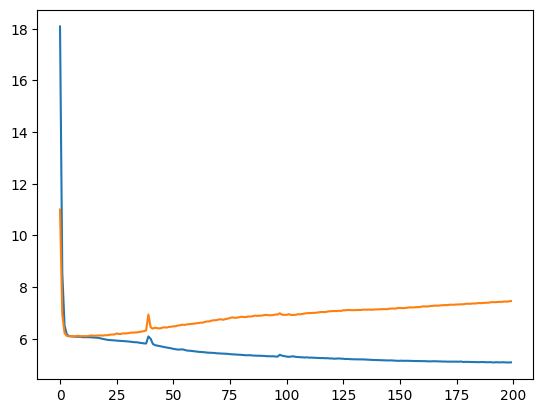

In [26]:
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [30]:
lstm_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    LSTM(128),
    Dropout(0.2),
    Dense(total_words, activation='softmax',kernel_regularizer=l2(0.1))
])

lstm_model.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0,validation_split=0.2)
print("LSTM training completed")

LSTM training completed


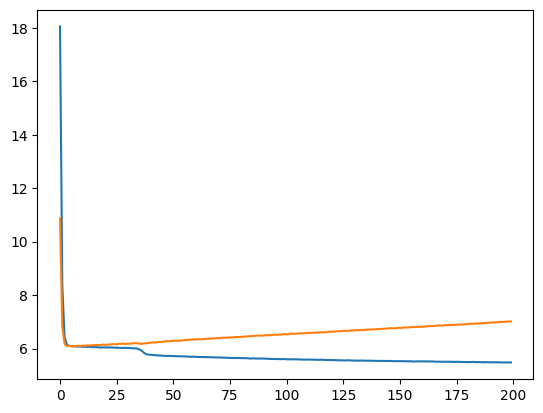

In [31]:
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [32]:
gru_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    GRU(128),
    Dropout(0.2),
    Dense(total_words, activation='softmax',kernel_regularizer= l2(0.1))
])

gru_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0,validation_split=0.2)
print("GRU training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU training completed


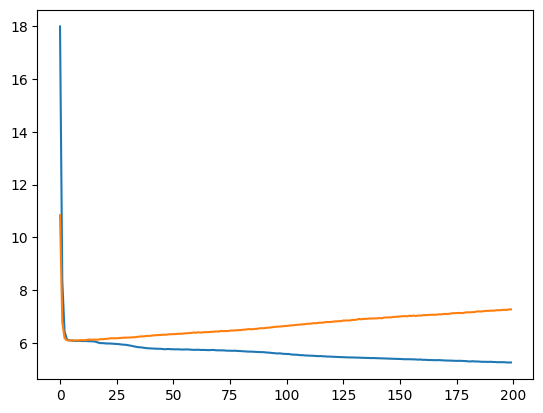

In [33]:
plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])

## 📉 Compare Training Loss

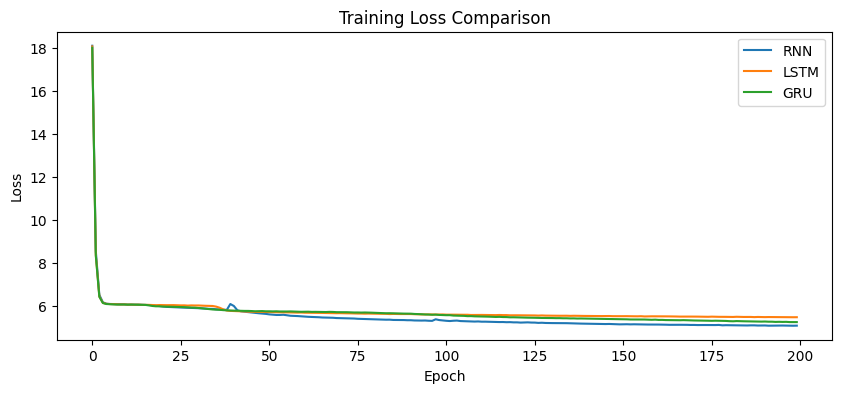

In [34]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [35]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [43]:
print("RNN :", generate_text(rnn_model, "Oh–Hey", 10))
print("LSTM:", generate_text(lstm_model, "Oh–Hey", 10))
print("GRU :", generate_text(gru_model, "Oh–Hey", 10))

RNN : Oh–Hey it was the wedding of the wedding of her wedding
LSTM: Oh–Hey the wedding wedding wedding wedding wedding wedding wedding wedding wedding
GRU : Oh–Hey the wedding with and her wedding with and her something


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

# **Assignment 5 Completed ✅**